<a href="https://colab.research.google.com/github/kschlussler/506-practice-workflow/blob/main/ANNOTATED_Diabetes_Dataset_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Explanation for Cell 1
This cell imports necessary libraries.

In [ ]:
import pandas as pd   # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np   # linear algebra
import matplotlib.pyplot as plt  #graphs and plots
import seaborn as sns   #data visualizations
import csv # Some extra functionalities for csv  files - reading it as a dictionary
from lightgbm import LGBMClassifier #sklearn is for machine learning and statistical modeling including classification, regression, clustering and dimensionality reduction

from sklearn.model_selection import train_test_split, cross_validate   #break up dataset into train and test sets

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

### Explanation for Cell 2
This cell imports libraries required for:
- Handling and visualizing missing data (`missingno`, `re`)
- Using a range of machine learning algorithms: Logistic Regression, Decision Trees, Random Forest, SVMs, Gradient Boosting, XGBoost, and CatBoost
- Evaluating model performance with metrics like accuracy, recall, precision, and AUC
- Splitting data and tuning hyperparameters using train-test split, `GridSearchCV`, and `RandomizedSearchCV`

In [ ]:
# importing python library for working with missing data
import missingno as msno
# To install missingno use: !pip install missingno
import re    # This library is used to perform regex pattern matching

# import various functions from sklearn
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, classification_report, make_scorer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

### Explanation for Cell 3
This cell sets up the full machine learning preprocessing and evaluation environment:
- Importing advanced cross-validation tools (e.g., `StratifiedKFold`, `RepeatedStratifiedKFold`)
- Preprocessing modules like imputation, scaling, and encoding for numeric and categorical variables
- Assembling complex pipelines using `Pipeline` and `ColumnTransformer`
- SMOTE for handling class imbalance
- Plotly for interactive visualizations
- Suppressing warnings for cleaner output

In [ ]:
from sklearn.model_selection import KFold,cross_val_score, RepeatedStratifiedKFold,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.compose import make_column_transformer
from imblearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score,\
                            precision_score, recall_score, roc_auc_score,\
                            classification_report, f1_score

import plotly
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import warnings
warnings.filterwarnings("ignore")

### Explanation for Cell 4
This cell loads dataset(s) into pandas DataFrame(s) using `pd.read_csv`.

In [ ]:
# Upload datasets
diabetic_data = pd.read_csv('diabetic_data.csv')
ids_mapping = pd.read_csv('IDS_mapping.csv')

### Explanation for Cell 5
This cell uses `.head()` to display the first few rows of the diabetic_data DataFrame. This gives a quick preview of the dataset's structure and content.

In [ ]:
diabetic_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Explanation for Cell 6
This cell uses `.head()` to display the first few rows of the ids_mapping DataFrame. This gives a quick preview of the dataset's structure and content.

In [ ]:
ids_mapping.head()

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


### Explanation for Cell 7
This cell replaces missing values '?' with Nan values in the DataFrame to clean categorical variables.

In [ ]:
# Replace missing value'?' with NaN
diabetic_data.replace('?', pd.NA, inplace=True)

### Explanation for Cell 8
This cell converts the readmitted column to numeric values.

In [ ]:
# Convert readmitted column to numeric values
# Standardize 'readmitted' values: "NO" → 0, ">30" → 1, "<30" → 2
diabetic_data['readmitted'] = diabetic_data['readmitted'].replace({'NO': 0, '>30': 1, '<30': 2}).astype(int)

### Explanation for Cell 9
This cell converts admission_type_id to numeric values in both datasets.

In [ ]:
# Convert admission_type_id in both datasets to numeric values
diabetic_data['admission_type_id'] = pd.to_numeric(diabetic_data['admission_type_id'], errors='coerce')
ids_mapping['admission_type_id'] = pd.to_numeric(ids_mapping['admission_type_id'], errors='coerce')

### Explanation for Cell 10
This cell drops duplicates from the DataFrame using `.drop()`.

In [ ]:
# Remove duplicates, keeping the first occurrence
diabetic_data.drop_duplicates(subset='patient_nbr', keep='first', inplace=True)

### Explanation for Cell 11
This cell drops rows where 'description' is missing in ids_mapping.

In [ ]:
# Drop rows where 'description' is missing in IDS_mapping
ids_mapping.dropna(subset=['description'], inplace=True)

### Explanation for Cell 12
This cell saves the cleaned data to csv files.

In [ ]:
# Save cleaned data
diabetic_data.to_csv("cleaned_diabetic_data.csv", index=False)
ids_mapping.to_csv("cleaned_IDS_mapping.csv", index=False)

### Explanation for Cell 13
This cell uses `.head()` to display the first few rows of both DataFrames.

In [ ]:
# Display cleaned datasets
display(diabetic_data.head())
display(ids_mapping.head())

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),<NA>,6,25,1,1,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),<NA>,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),<NA>,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),<NA>,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,0


,admission_type_id,description
0,1.0,Emergency
1,2.0,Urgent
2,3.0,Elective
3,4.0,Newborn
4,5.0,Not Available


### Explanation for Cell 14
This cell imports necessary tools.

In [ ]:
import plotly
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import warnings
warnings.filterwarnings("ignore")

### Explanation for Cell 15
This cell uses the `.info()` method to provide a summary of the DataFrame including column names, non-null counts, data types, and memory usage. It's helpful for assessing structure and missing values.

In [ ]:
diabetic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71518 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              71518 non-null  int64 
 1   patient_nbr               71518 non-null  int64 
 2   race                      69570 non-null  object
 3   gender                    71518 non-null  object
 4   age                       71518 non-null  object
 5   weight                    2853 non-null   object
 6   admission_type_id         71518 non-null  int64 
 7   discharge_disposition_id  71518 non-null  int64 
 8   admission_source_id       71518 non-null  int64 
 9   time_in_hospital          71518 non-null  int64 
 10  payer_code                40475 non-null  object
 11  medical_specialty         37041 non-null  object
 12  num_lab_procedures        71518 non-null  int64 
 13  num_procedures            71518 non-null  int64 
 14  num_medications           

### Explanation for Cell 16
This cell checks for missing values in the DataFrame by using `.isnull().sum()`. It returns the number of missing entries for each column.

In [ ]:
diabetic_data.duplicated().sum()

0

### Explanation for Cell 17
This cell uses the `missingno` library to visualize missing data patterns with bar charts. It helps identify which features have many missing values.

<Axes: >

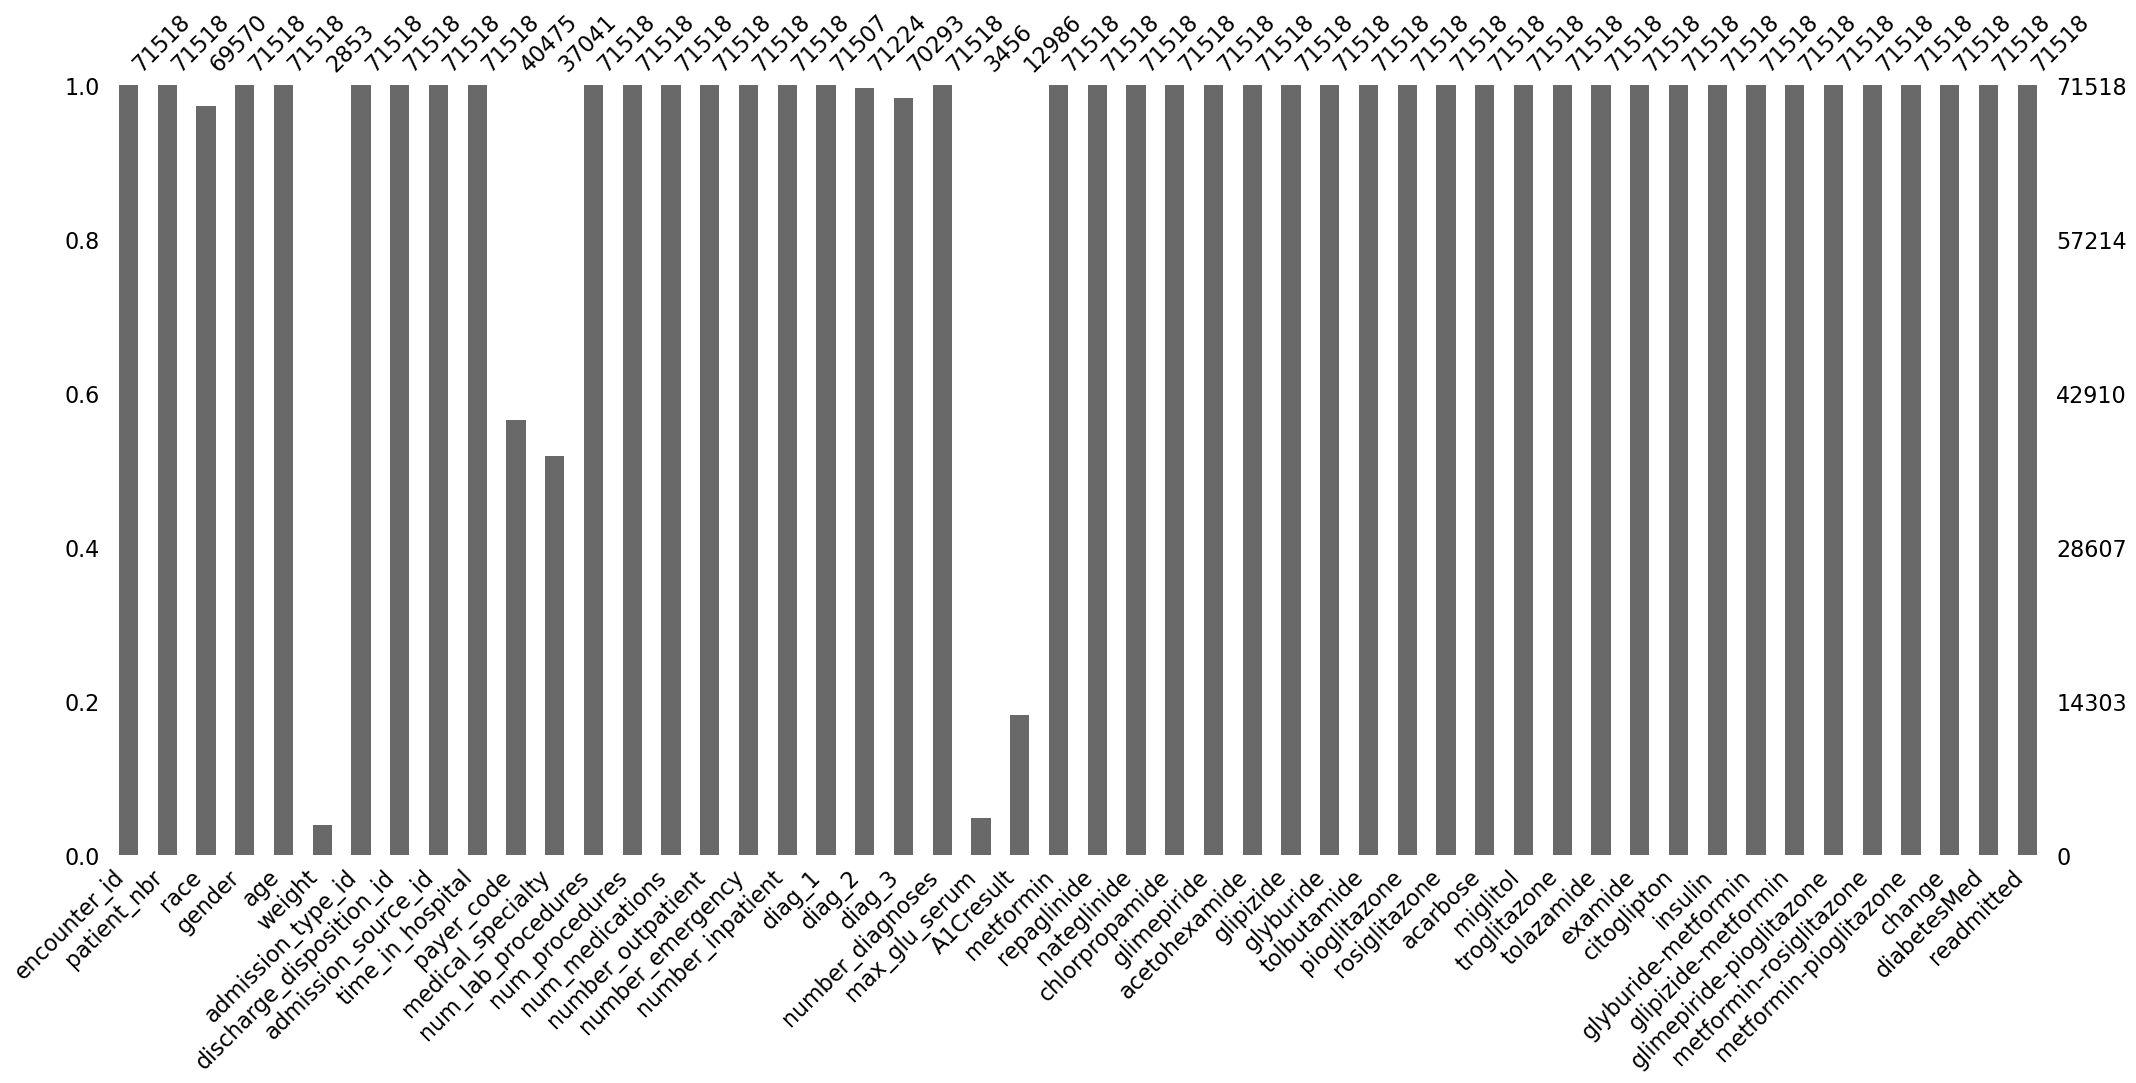

In [ ]:
msno.bar(diabetic_data)

### Explanation for Cell 18
This cell uses the `missingno` library to visualize missing data patterns with matrices. It helps identify which features have many missing values.

<Axes: >

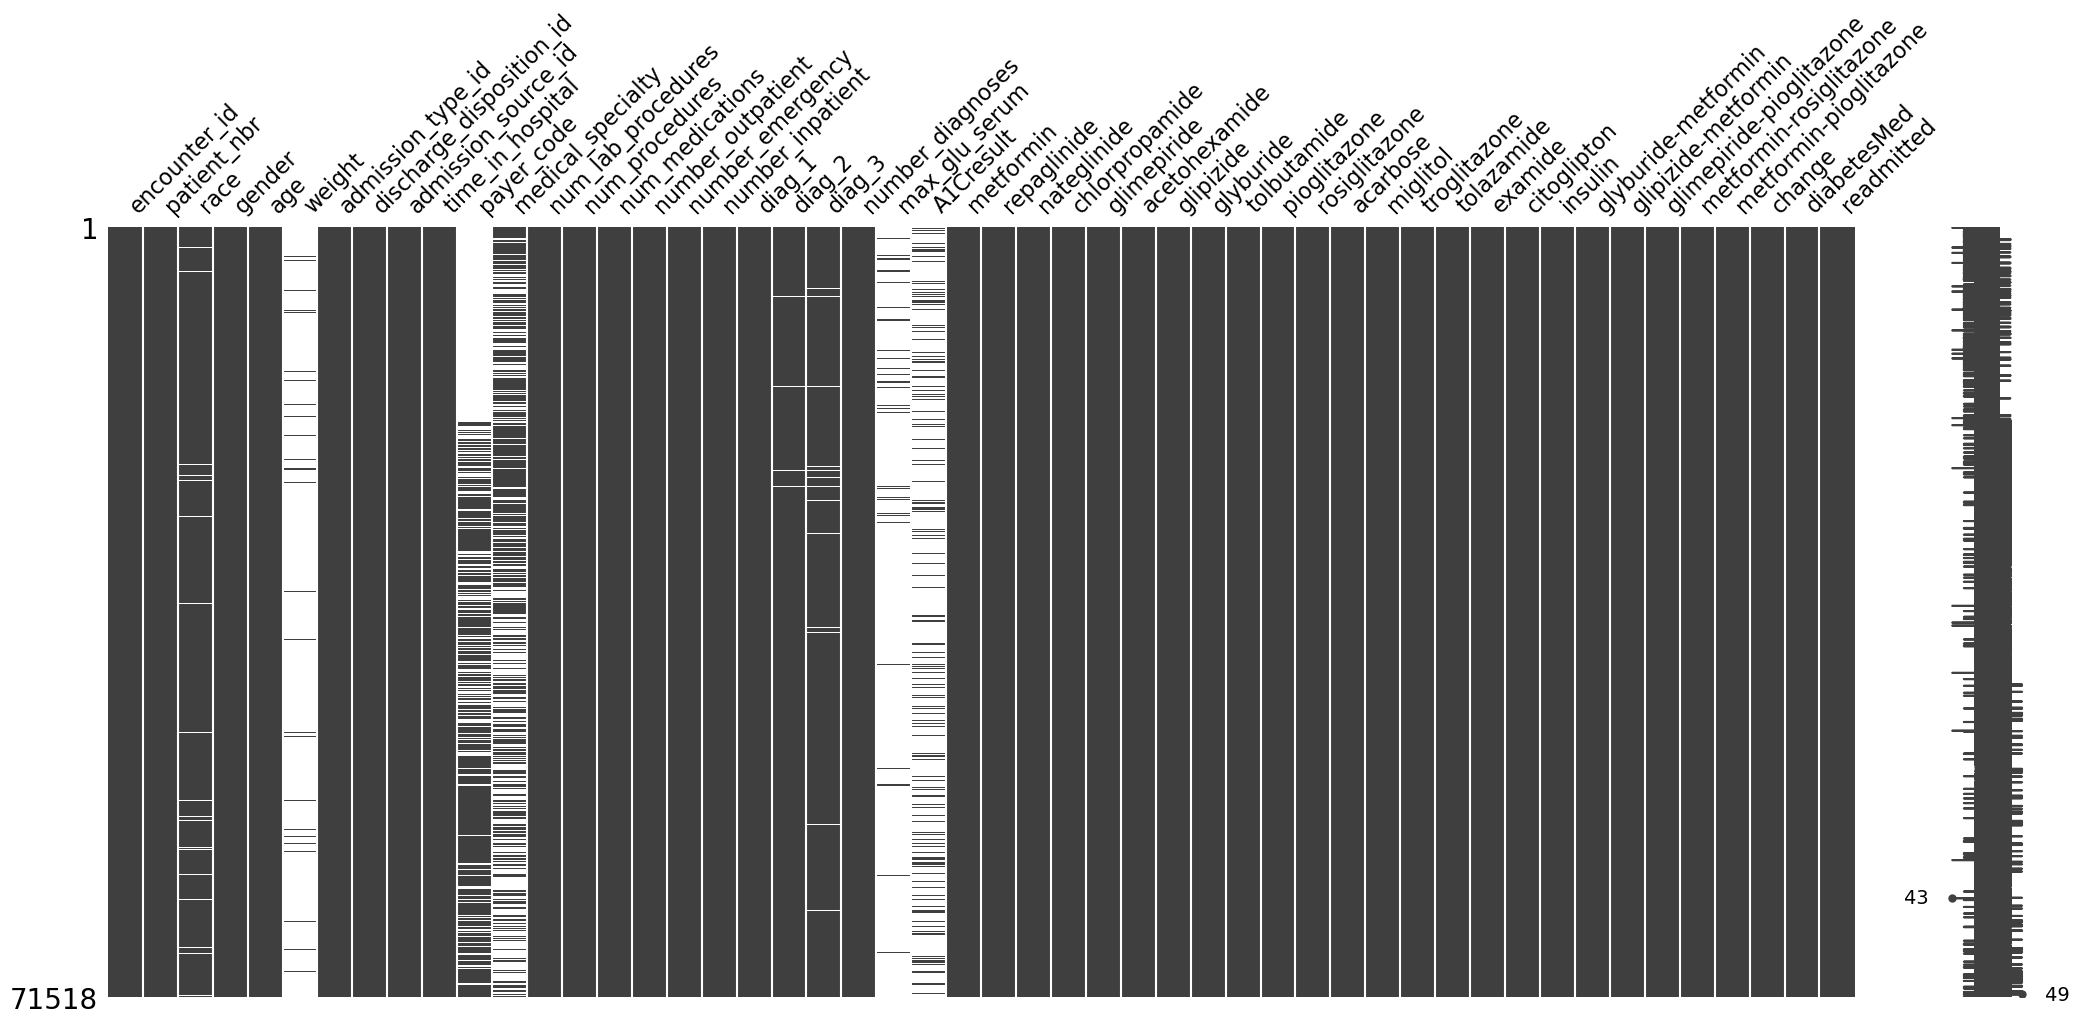

In [ ]:
msno.matrix(diabetic_data)

### Explanation for Cell 19
This cell uses `.head()` to display the first few rows of the DataFrame.

In [ ]:
diabetic_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),<NA>,6,25,1,1,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),<NA>,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),<NA>,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),<NA>,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,0


### Explanation for Cell 20
This cell categorizes columns into numerical and categorical values.

In [ ]:
numerical = ['time_in_hospital', 'num_medications', 'number_diagnoses', 'readmitted', 'num_lab_procedures', 'num_procedures', 'number_outpatient', 'number_emergency', 'number_inpatient']

categorical = ['race', 'gender', 'insulin', 'change', 'diabetesMed', 'weight', 'age', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult']

### Explanation for Cell 21
This cell displays the count, mean, std, min, 25%, 50%, 75%, and max values for the numerical data.

In [ ]:
diabetic_data[numerical].describe()

,time_in_hospital,num_medications,number_diagnoses,readmitted,num_lab_procedures,num_procedures,number_outpatient,number_emergency,number_inpatient
count,71518.00000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000
mean,4.28913,15.705025,7.245700,0.486954,43.075478,1.430577,0.280069,0.103540,0.177829
std,2.94921,8.311163,1.994674,0.652548,19.952338,1.759864,1.068957,0.509187,0.603790
min,1.00000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.00000,10.000000,6.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000
50%,3.00000,14.000000,8.000000,0.000000,44.000000,1.000000,0.000000,0.000000,0.000000
75%,6.00000,20.000000,9.000000,1.000000,57.000000,2.000000,0.000000,0.000000,0.000000
max,14.00000,81.000000,16.000000,2.000000,132.000000,6.000000,42.000000,42.000000,12.000000


### Explanation for Cell 22
This cell displays the count, unique, top, and freq values for the categorical data.

In [ ]:
diabetic_data[categorical].describe()

,race,gender,insulin,change,diabetesMed,weight,age,payer_code,medical_specialty,max_glu_serum,A1Cresult
count,69570,71518,71518,71518,71518,2853,71518,40475,37041,3456,12986
unique,5,3,4,2,2,9,10,17,70,3,3
top,Caucasian,Female,No,No,Yes,[75-100),[70-80),MC,InternalMedicine,Norm,>8
freq,53491,38025,34921,39494,54319,1195,18210,20414,10919,1731,6304


### Explanation for Cell 23
This cell checks for missing values in the DataFrame by using `.isnull().sum()`. It returns the number of missing entries for each column.

In [ ]:
# Check missing values in the dataset
missing_values = diabetic_data.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Show only columns with missing values
print(missing_values)

race                  1948
weight               68665
payer_code           31043
medical_specialty    34477
diag_1                  11
diag_2                 294
diag_3                1225
max_glu_serum        68062
A1Cresult            58532
dtype: int64


### Explanation for Cell 24
This cell drops weight columns from the DataFrame using `.drop()` due to the high number of missing values.

In [ ]:
diabetic_data['weight'] = pd.to_numeric(diabetic_data['weight'], errors='coerce')  # Ensure it's numeric
diabetic_data['weight'].fillna(diabetic_data['weight'].median(), inplace=True)

diabetic_data.drop(columns=['weight'], inplace=True)  # Only if you decide it's not useful

### Explanation for Cell 25
This cell separates numerical and categorical columns amd imputes missing values.

In [ ]:
# Separate numerical and categorical columns
num_cols = diabetic_data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = diabetic_data.select_dtypes(include=['object']).columns

# Impute missing values
for col in num_cols:
    diabetic_data[col].fillna(diabetic_data[col].median(), inplace=True)  # Median for numeric

for col in cat_cols:
    diabetic_data[col].fillna(diabetic_data[col].mode()[0], inplace=True)  # Mode for categorical

### Explanation for Cell 26
This cell checks for missing values in the DataFrame by using `.isnull().sum()`. It returns the number of missing entries for each column.

In [ ]:
print(diabetic_data.isnull().sum().sum())  # Should print 0 if all missing values are filled


0


### Explanation for Cell 27
This cell displays unique value counts for each column.

In [ ]:
# Display unique value counts for each column
unique_counts = diabetic_data.nunique().sort_values(ascending=True)
print(unique_counts)

glimepiride-pioglitazone        1
citoglipton                     1
examide                         1
troglitazone                    2
change                          2
metformin-pioglitazone          2
metformin-rosiglitazone         2
glipizide-metformin             2
acetohexamide                   2
tolazamide                      2
diabetesMed                     2
tolbutamide                     2
A1Cresult                       3
max_glu_serum                   3
readmitted                      3
gender                          3
acarbose                        3
rosiglitazone                   4
pioglitazone                    4
miglitol                        4
glyburide                       4
glipizide                       4
insulin                         4
glyburide-metformin             4
glimepiride                     4
chlorpropamide                  4
repaglinide                     4
metformin                       4
nateglinide                     4
race          

### Explanation for Cell 28
This cell displays unique values for categorical columns ('cat_cols')

In [ ]:
cat_cols = diabetic_data.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(diabetic_data[col].unique())


Column: race
['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']

Column: gender
['Female' 'Male' 'Unknown/Invalid']

Column: age
['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']

Column: payer_code
['MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']

Column: medical_specialty
['Pediatrics-Endocrinology' 'InternalMedicine' 'Family/GeneralPractice'
 'Cardiology' 'Surgery-General' 'Orthopedics' 'Gastroenterology'
 'Surgery-Cardiovascular/Thoracic' 'Nephrology'
 'Orthopedics-Reconstructive' 'Psychiatry' 'Emergency/Trauma'
 'Pulmonology' 'Surgery-Neuro' 'Obsterics&Gynecology-GynecologicOnco'
 'ObstetricsandGynecology' 'Pediatrics' 'Hematology/Oncology'
 'Otolaryngology' 'Surgery-Colon&Rectal' 'Pediatrics-CriticalCare'
 'Endocrinology' 'Urology' 'Psychiatry-Child/Adolescent'
 'Pediatrics-Pulmonology' 'Anesthesiology-Pediatric' 'Radiology'
 'Pediatrics-Hematology-Oncology' 'Psychology' 'Neurolog

### Explanation for Cell 29
This cell displays unique values for numerical columns ('num_cols')

In [ ]:
num_cols = diabetic_data.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    print(f"\nColumn: {col}")
    print(f"Unique values: {diabetic_data[col].unique()[:10]}")  # Show first 10 unique values


Column: encounter_id
Unique values: [2278392  149190   64410  500364   16680   35754   55842   63768   12522
   15738]

Column: patient_nbr
Unique values: [  8222157  55629189  86047875  82442376  42519267  82637451  84259809
 114882984  48330783  63555939]

Column: admission_type_id
Unique values: [6 1 2 3 4 5 8 7]

Column: discharge_disposition_id
Unique values: [25  1  3  6  2  5 11  7 10 14]

Column: admission_source_id
Unique values: [ 1  7  2  4  5  6 20  3 17  8]

Column: time_in_hospital
Unique values: [ 1  3  2  4  5 13 12  9  7 10]

Column: num_lab_procedures
Unique values: [41 59 11 44 51 31 70 73 68 33]

Column: num_procedures
Unique values: [0 5 1 6 2 3 4]

Column: num_medications
Unique values: [ 1 18 13 16  8 21 12 28 17 11]

Column: number_outpatient
Unique values: [ 0  2  1  5  7  3  8  4 12  9]

Column: number_emergency
Unique values: [0 1 2 4 9 5 3 6 8 7]

Column: number_inpatient
Unique values: [0 1 2 3 5 4 6 9 8 7]

Column: number_diagnoses
Unique values: [ 1  9  

### Explanation for Cell 30
This cell uses `.head()` to display the first few rows of the DataFrame to view changes made.

In [ ]:
diabetic_data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,MC,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,MC,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,MC,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,MC,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,MC,...,No,Steady,No,No,No,No,No,Ch,Yes,0


### Explanation for Cell 31
This cell uses the `.info()` method to provide a summary of the DataFrame including column names, non-null counts, data types, and memory usage. It's helpful for assessing structure and missing values.

In [ ]:
diabetic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71518 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              71518 non-null  int64 
 1   patient_nbr               71518 non-null  int64 
 2   race                      71518 non-null  object
 3   gender                    71518 non-null  object
 4   age                       71518 non-null  object
 5   admission_type_id         71518 non-null  int64 
 6   discharge_disposition_id  71518 non-null  int64 
 7   admission_source_id       71518 non-null  int64 
 8   time_in_hospital          71518 non-null  int64 
 9   payer_code                71518 non-null  object
 10  medical_specialty         71518 non-null  object
 11  num_lab_procedures        71518 non-null  int64 
 12  num_procedures            71518 non-null  int64 
 13  num_medications           71518 non-null  int64 
 14  number_outpatient         

### Explanation for Cell 32
This cell provides visuals for numerical data.

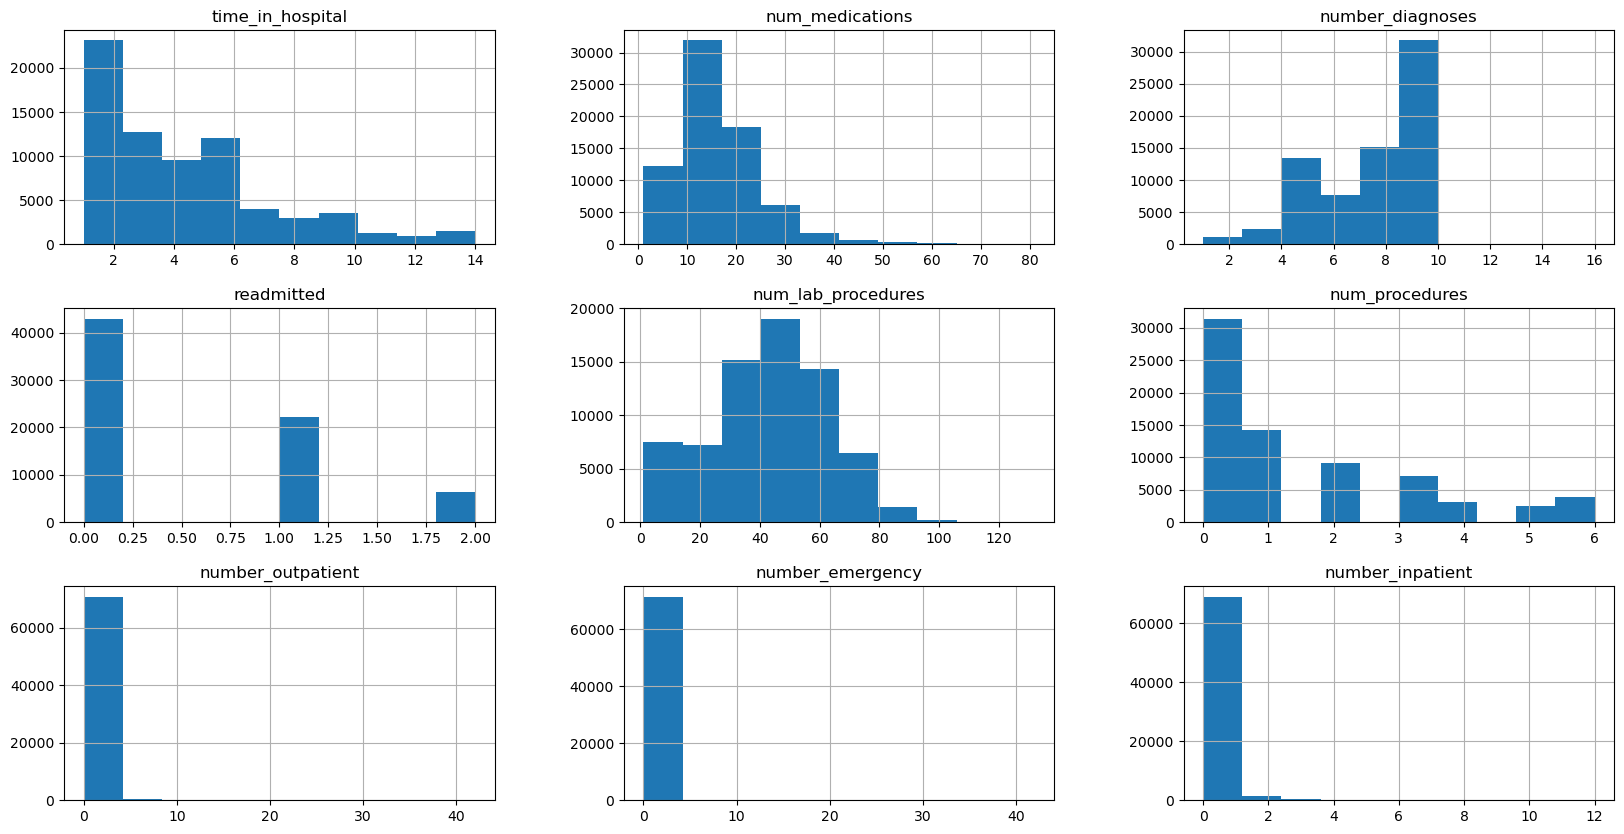

In [ ]:
diabetic_data[numerical].hist(figsize=(20,10));

In [ ]:
#### Session 4
### Linear Regression

### Explanation for Cell 33
This cell uses get_dummies to convert categorical values to numerical

In [ ]:
## Converting Categorical Features into Numeric Features
#using get_dummies from the pandas library to convert categorical features to numeric
diabetic_data = pd.get_dummies(diabetic_data, drop_first = False)

### Explanation for Cell 34
This cell breaks up the data into Train & Test

In [ ]:
# Breaking the data up into Train & Test
train_df, valid_df, test_df = np.split(diabetic_data.sample(frac=1, random_state=42),
                                        [int(.7*len(diabetic_data)), int(0.85*len(diabetic_data))])
train_df = train_df.reset_index(drop = True)
valid_df = valid_df.reset_index(drop = True)
test_df = test_df.reset_index(drop = True)

### Explanation for Cell 35
This cell uses `.value_counts()` to count the unique values in a column, helping analyze the distribution of categorical features.

In [ ]:
diabetic_data.readmitted.value_counts()

readmitted
0    42985
1    22240
2     6293
Name: count, dtype: int64

### Explanation for Cell 36
This cell replaces 2 with 0 to make the readmitted column binary.

In [ ]:
# Convert readmitted to binary
diabetic_data["readmitted"] = diabetic_data["readmitted"].astype(int)
diabetic_data["readmitted"] = diabetic_data["readmitted"].replace({2: 0})

diabetic_data.readmitted.value_counts()

readmitted
0    49278
1    22240
Name: count, dtype: int64

### Explanation for Cell 37
This cell prints the unique values of the readmitted column post binary conversion.

In [ ]:
print(diabetic_data["readmitted"].unique())  # Should output only [0, 1]

[0 1]


### Explanation for Cell 38
train_df is used to train the model so that the algorithm can learn patterns from this data.

I used readmitted.value_counts() to count how many times each unique value appears in that column.

In [ ]:
train_df["readmitted"] = train_df["readmitted"].replace({2: 0})
train_df.readmitted.value_counts()

readmitted
0    34414
1    15648
Name: count, dtype: int64

### Explanation for Cell 39
valid_df is used to tune the model's hyperparameters and prevent overfitting.

valid_df.readmitted.value.counts() counts the frequency of each class in the readmitted column.

In [ ]:
valid_df["readmitted"] = valid_df["readmitted"].replace({2: 0})
valid_df.readmitted.value_counts()

readmitted
0    7462
1    3266
Name: count, dtype: int64

### Explanation for Cell 40
test_df is used to evaluate final model performance on unseen data.

This cell displays the number of occurences of each unique value in the readmitted column.

In [ ]:
test_df["readmitted"] = test_df["readmitted"].replace({2: 0})
test_df.readmitted.value_counts()

readmitted
0    7402
1    3326
Name: count, dtype: int64

### Explanation for Cell 41
This cell helps to treat the imbalance in the dataset because it calculates the proportion of positive cases in the binary classification list (y_actual).

In [ ]:
# Treating the Imbalance in the Data
def calc_prevalence(y_actual):
    return (sum(y_actual)/len(y_actual))

### Explanation for Cell 42
This cell splits the training data into positive and negative subsets based on the readmitted column.
    - Line 1 creates a boolean series where each value is True if the readmitted value is 1 (positive class), and False if otherwise.
    - Line 2 filters the train_df to get only the rows where readmitted == 2 (positive class) and stores it in a new dataframe (df_train_pos).
    - Line 3 uses the inverse(~) of the boolean mask to select rows where readmitted != 1 (negative class) and stores it in df_train_neg.

In [ ]:
# split the training data into positive and negative
rows_pos =train_df.readmitted == 1
df_train_pos = train_df.loc[rows_pos]
df_train_neg = train_df.loc[~rows_pos]

### Explanation for Cell 43
This cell creates a balanced training dataset by combining all positive cases with a random sample of negative cases of equal size to fix the class imbalance in the training data which can hurt the model performance.

In [ ]:
# merge the balanced data
readmitted_df_balanced = pd.concat([df_train_pos, df_train_neg.sample(n = len(df_train_pos), random_state = 111)],axis = 0)

### Explanation for Cell 44
This cell shuffles the balanced dataset and then prints the prevalence (proportion of positives) in that shuffled training data.
The output of 0.500 (50%) confirms that the positive and negative cases are now equally represented/balanced.

In [ ]:
# shuffle the order of training samples
readmitted_df_balanced = readmitted_df_balanced.sample(n = len(readmitted_df_balanced), random_state = 42).reset_index(drop = True)

print('Train balanced prevalence(n = %d):%.3f'%(len(readmitted_df_balanced), \
                                                calc_prevalence(readmitted_df_balanced.readmitted.values)))

Train balanced prevalence(n = 31296):0.500


### Explanation for Cell 45
This cell uses `.value_counts()` to count the unique values in the balanced data.

In [ ]:
readmitted_df_balanced.readmitted.value_counts()

readmitted
0    15648
1    15648
Name: count, dtype: int64

### Explanation for Cell 46
This cell defines the features (X) and target (y) for the training, validation, and test datasets by splitting each datafram into input variables and labels.

Training Set:
- X_train: All columns except:
    - 'readmitted' (the target label)
    - 'envounter_id', 'patient_nbr' (ID columsn that shouldnt be used for prediction)
- y_train: the target variable (wether a patient was readmitted [0 or 1])

Validation Set:
- Prepares X and y for the validation set, using the same column exclusions
- This set is used for model tuning and performance monitoring during training

Test Set:
- Creates X and y for final evaluation
- This set should remain untouched during training and is used to report final model performance

In [ ]:
# Define features (X) and target (y) for the balanced training dataset
X_train = readmitted_df_balanced.drop(['readmitted', 'encounter_id', 'patient_nbr'], axis=1, errors='ignore')
y_train = readmitted_df_balanced['readmitted']

# Define features and target for validation dataset
X_valid = valid_df.drop(['readmitted', 'encounter_id', 'patient_nbr'], axis=1, errors='ignore')
y_valid = valid_df['readmitted']

# Define features and target for test dataset
X_test = test_df.drop(['readmitted', 'encounter_id', 'patient_nbr'], axis=1, errors='ignore')
y_test = test_df['readmitted']

### Explanation for Cell 47
This cell creates an instance of the StandardScaler from sklearn.preprocessing.
It's purpose is to standardize features be removing the mean and scaling the unit variance so that after transformation each feature will have a mean of 0 and a standard deviation of 1. This is essential for machine learning algorithms, like logistic regession, that are  sensitive to the scale of input features.

In [ ]:
scaler=StandardScaler()

### Explanation for Cell 48
This cell identifies all numerical feature columns in the training dataset X_train and stores the list in the varible 'num_cols'.

In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

### Explanation for Cell 49
This cell applies the standardization (scaling) to the numeric features in the training, validation, and test datasets using the StandardScaler previously defined in Cell 47.

In [ ]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid[num_cols] = scaler.transform(X_valid[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### Explanation for Cell 50
This cell performs a re-split of the dataset after full cleaning/preprocessing.
- Section 1 Recreates X and y from full cleaned data
- Section 2 Re-splits the full dataset into training and validation sets
- Section 3 Applies SelectKBest for feature selection
The purpose of this is to reduce dimensionality, improve model performance, and speed up training. It also helps focus on the most relevant features for predicting readmission.

In [ ]:
# Recreate X and y from the full cleaned/preprocessed dataset
X = diabetic_data.drop(columns=['readmitted', 'patient_nbr', 'encounter_id'], errors='ignore')
y = diabetic_data['readmitted']

# Re-split after all preprocessing
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Now apply SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=100)
X_train_k = selector.fit_transform(X_train, y_train)
X_valid_k = selector.transform(X_valid)


### Explanation for Cell 51
This cell ensures that the validation dataset has the same columns in the same order as the training set and then applies the previously fiitted SelectKBest selector to the aligned validation set.

In [ ]:
X_valid = X_valid[X_train.columns]

X_valid_k = selector.transform(X_valid)

### Explanation for Cell 52
This cell does the same thing as cell 51 (I'm just scared to delete it lol).

In [ ]:
# Ensure consistent columns before SelectKBest
X_valid = X_valid[X_train.columns]

# Feature selection
selector = SelectKBest(score_func=f_classif, k=100)
X_train_k = selector.fit_transform(X_train, y_train)
X_valid_k = selector.transform(X_valid)

### Explanation for Cell 53
This cell summarizes the numerical columns from the training, validation, and test sets after scaling. This confirms that StandardScaler worked correctly.

In [ ]:
print(X_train[num_cols].describe())  # Mean should be ~0, Std should be ~1
print(X_valid[num_cols].describe())  # Should have similar scalingprint(X_test[num_cols].describe())   # Should have similar scaling

       admission_type_id  discharge_disposition_id  admission_source_id  \
count       57214.000000              57214.000000         57214.000000   
mean            2.098577                  3.584123             5.655661   
std             1.507038                  5.262406             4.161243   
min             1.000000                  1.000000             1.000000   
25%             1.000000                  1.000000             1.000000   
50%             1.000000                  1.000000             7.000000   
75%             3.000000                  3.000000             7.000000   
max             8.000000                 28.000000            25.000000   

       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count      57214.000000        57214.000000    57214.000000     57214.000000   
mean           4.284860           43.090572        1.429021        15.716206   
std            2.942285           19.977354        1.759356         8.315810   
min 

### Explanation for Cell 54
This cell calculates specificity and prints a comprehensive classification report using predicted probabilities and a classification threshold.

In [ ]:
def calc_specificity(y_actual, y_pred, thresh):
    return sum((y_pred < thresh) & (y_actual == 0)) / sum(y_actual == 0)

def print_report(y_actual, y_pred, thresh=0.5):
    auc = roc_auc_score(y_actual, y_pred)
    accuracy = accuracy_score(y_actual, (y_pred > thresh))
    recall = recall_score(y_actual, (y_pred > thresh))
    precision = precision_score(y_actual, (y_pred > thresh))
    specificity = calc_specificity(y_actual, y_pred, thresh)

    print(f"AUC: {auc:.3f}")
    print(f"accuracy: {accuracy:.3f}")
    print(f"recall: {recall:.3f}")
    print(f"precision: {precision:.3f}")
    print(f"specificity: {specificity:.3f}")
    print(f"prevalence: {sum(y_actual)/len(y_actual):.3f}")
    print()

    return auc, accuracy, recall, precision, specificity


### Explanation for Cell 55
This cell performs feature selection, hyperparameter tuning for a logistic regression model, and evaluates the model using the custon print_report() function.

In [ ]:
# === Feature Selection ===
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Convert to NumPy arrays to avoid feature name mismatch
X_train_k = selector.fit_transform(X_train.values, y_train)
X_valid_k = selector.transform(X_valid.values)

# === Hyperparameter Tuning ===
param_grid = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'class_weight': ['balanced']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_k, y_train)

# Evaluate best model
best_model = grid.best_estimator_
y_valid_preds = best_model.predict_proba(X_valid_k)[:, 1]

print("Best Parameters:", grid.best_params_)
print_report(y_valid, y_valid_preds)


Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
AUC: 0.624
accuracy: 0.591
recall: 0.575
precision: 0.393
specificity: 0.599
prevalence: 0.311



(0.6240744873662759,
 0.5914429530201343,
 0.5753147482014388,
 0.39284617746392386,
 0.5987215909090909)

### Explanation for Cell 56
This cell apples standard scaling to time_in_hospital and num_medications acress the training, validation, and test datasets. This is to ensure model performace isnt skewed due to unscaled numeric values.

In [ ]:
X_train[['time_in_hospital', 'num_medications']] = pd.DataFrame(scaler.fit_transform(X_train[['time_in_hospital', 'num_medications']]),columns=['time_in_hospital', 'num_medications'])
X_valid[['time_in_hospital', 'num_medications']] = pd.DataFrame(scaler.transform(X_valid[['time_in_hospital', 'num_medications']]),columns=['time_in_hospital', 'num_medications'])
X_test[['time_in_hospital', 'num_medications']] = pd.DataFrame(scaler.transform(X_test[['time_in_hospital', 'num_medications']]),columns=['time_in_hospital', 'num_medications'])

### Explanation for Cell 57
This cell uses `.head()` to display the first few rows of the training DataFrame.

In [ ]:
X_train.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,glipizide-metformin_Steady,glimepiride-pioglitazone_No,metformin-rosiglitazone_No,metformin-rosiglitazone_Steady,metformin-pioglitazone_No,metformin-pioglitazone_Steady,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
81573,3,1,1,NaN,47,2,NaN,0,0,0,...,False,True,True,False,True,False,True,False,False,True
85079,1,1,7,NaN,29,0,NaN,0,0,0,...,False,True,True,False,True,False,True,False,False,True
14146,1,18,7,0.243058,45,1,0.875905,0,0,0,...,False,True,True,False,True,False,False,True,True,False
36211,1,3,6,-0.776567,48,2,-0.446888,0,0,0,...,False,True,True,False,True,False,False,True,False,True
23149,1,1,7,1.262683,46,5,0.394889,0,0,0,...,False,True,True,False,True,False,True,False,False,True


### Explanation for Cell 58
This cell checks for missing values in the DataFrame by using `.isnull().sum()`. It returns the number of missing entries for each column.

In [ ]:
print(X_train.isnull().sum().sum())  # Should print 0
print(X_valid.isnull().sum().sum())  # Should print 0
print(X_test.isnull().sum().sum())   # Should print 0

45132
24040
0


### Explanation for Cell 59
This cell fits a machine learning model to training data and uses it to predict outcomes on test/validation data.

In [ ]:
### Logistic Regression# Fit Logistic Regression on top 100 selected features
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced', random_state=42)
log_reg.fit(X_train_k, y_train)

# Predict probabilities
y_valid_preds = log_reg.predict_proba(X_valid_k)[:, 1]

# Evaluate model
print("Logistic Regression Performance (Threshold = 0.5):")
log_auc, log_accuracy, log_recall, log_precision, log_specificity = print_report(y_valid, y_valid_preds, thresh=0.5)


Logistic Regression Performance (Threshold = 0.5):
AUC: 0.624
accuracy: 0.589
recall: 0.578
precision: 0.391
specificity: 0.594
prevalence: 0.311



### Explanation for Cell 60
This cell evaluates how the logistic regression model performs at multiple classification thresholds.
- The purpose of this is to help understand the trade-offs between:
    - Recall (sensitivity) vs. Precision
    - Specificity (true negative rate)
    - Overall accuracy and AUC

- A lower threshold (e.g., 0.3) may:
    - Catch more positives (↑ recall)
    - But also increase false positives (↓ precision, ↓ specificity)
- A higher threshold (e.g., 0.6) may:
    - Reduce false positives (↑ precision, ↑ specificity)
    - But miss actual positives (↓ recall)
- This is important in healthcare settings to optimize for:
    - Recall -> minimize missed diagnoses (false negatives)
    - Specificity -> avoid unnecessary treatments (false Positives)

In [ ]:
for t in [0.3, 0.4, 0.5, 0.6]:
    print(f"\nThreshold = {t}")
    print_report(y_valid, y_valid_preds, thresh=t)



Threshold = 0.3
AUC: 0.624
accuracy: 0.345
recall: 0.980
precision: 0.320
specificity: 0.059
prevalence: 0.311


Threshold = 0.4
AUC: 0.624
accuracy: 0.439
recall: 0.876
precision: 0.343
specificity: 0.242
prevalence: 0.311


Threshold = 0.5
AUC: 0.624
accuracy: 0.589
recall: 0.578
precision: 0.391
specificity: 0.594
prevalence: 0.311


Threshold = 0.6
AUC: 0.624
accuracy: 0.676
recall: 0.232
precision: 0.459
specificity: 0.876
prevalence: 0.311



### Explanation for Cell 61
This cell calculates specificity (A.K.A. the true negative rate).

In [ ]:
def calc_specificity(y_actual, y_pred, thresh):
    # calculates specificity
    return sum((y_pred < thresh) & (y_actual == 0)) /sum(y_actual ==0)

### Explanation for Cell 62
This cell evaluates classification model performance using a custom threshold (0.5).

In [ ]:
def print_report(y_actual, y_pred, thresh = 0.5):
    auc = roc_auc_score(y_actual, y_pred)
    accuracy = accuracy_score(y_actual, (y_pred > thresh))
    recall = recall_score(y_actual, (y_pred > thresh))
    precision = precision_score(y_actual, (y_pred > thresh))
    specificity = calc_specificity(y_actual, y_pred, thresh)
    print('AUC:%.3f'%auc)
    print('accuracy:%.3f'%accuracy)
    print('recall:%.3f'%recall)
    print('precision:%.3f'%precision)
    print('specificity:%.3f'%specificity)
    print('prevalence:%.3f'%calc_prevalence(y_actual))
    print(' ')
    return auc, accuracy, recall, precision, specificity

### Explanation for Cell 63
This cell shows the predicted probabilities for the positive class (1) generated by the trained model on the validation set.

In [ ]:
y_valid_preds

array([0.67066571, 0.49009086, 0.48154858, ..., 0.47122869, 0.42274856,
       0.64270599])

In [ ]:
#### Session 5
### Decision Tree

### Explanation for Cell 64
This cell trains and evaluates a Decision Tree classifier using a controlled depth and the validation set.

In [ ]:
## Step 1: I started by training a simple DecisionTreeClassifier with a depth of 10. The model is trained on the dataset, and predictions are made on the validation set.

# Train Decision Tree with max_depth=10
dc_clf = DecisionTreeClassifier(random_state=42, max_depth = 10)
dc_clf.fit(X_train, y_train)

# Predict probabilities and labels
dc_preds_proba = dc_clf.predict_proba(X_valid)[:,1]
dc_preds = dc_clf.predict(X_valid)

## Step 2: The model's accuracy, AUC, recall, precision, and specificity are computed to understand its effectiveness.
# Evaluate performance
lr_valid_auc, lr_valid_accuracy, lr_valid_recall, \
    lr_valid_precision, lr_valid_specificity = print_report(y_valid,dc_preds_proba, 0.5)

AUC:0.606
accuracy:0.686
recall:0.076
precision:0.471
specificity:0.960
prevalence:0.311
 


### Explanation for Cell 65
This cell performs hyperparameter tuning using cross-validation to identify the best model configuration.

The output tells us that:
- I used RandomizedSearchCV to search over 20 combinations of decision tree parameters.
-It ran 2-fold cross-validation for each of the 20 combinations --> 40 model fits total
- The randomized search selected the best model -- a DecisionTreeClassifier with the best performing combination of hyperparameters based on recall (since I used recall_score as the custom scoring metric)

In [ ]:
## Step 3: I performed Hyperparameter Tuning using 'RandomizedSearchCV' to search for the best combination of parameters.

# Define parameter grid
dc_grid = {'max_features':['auto','sqrt'],
           'max_depth':range(1,11,1),
           'min_samples_split':range(2,10,2),
           'criterion':['gini','entropy']}

# Custom scoring metric for hyperparameter tuning
recall_scoring = make_scorer(recall_score)

# Perform Randomized Search
dc_random = RandomizedSearchCV(estimator = dc_clf, param_distributions = dc_grid,
                               n_iter = 20, cv = 2, scoring=recall_scoring,
                               verbose = 1, random_state = 111)
# Train model
dc_random.fit(X_train, y_train)

Fitting 2 folds for each of 20 candidates, totalling 40 fits


RandomizedSearchCV(cv=2,
                   estimator=DecisionTreeClassifier(max_depth=10,
                                                    random_state=42),
                   n_iter=20,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(1, 11),
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_split': range(2, 10, 2)},
                   random_state=111,
                   scoring=make_scorer(recall_score, response_method='predict'),
                   verbose=1)

### Explanation for Cell 66
This cell extracts the best hyperparameters.

What these mean:
- min_samples_split: 2
    - A node must have at least 2 samples to be split
    - This is the most flexible setting (can lead to overfitting if not paired with other limits)
- max_features: 'sqrt'
    - When considering splits, the model uses the square root of the number of features
    - A common default that adds randomness and helps generalization
- max_depth: 10
    - The tree is limited to a maximum depth of 10
    - Controls complexity to prevent overfitting
- criterion: 'entropy'
    - The tree uses information gain (entropy) rather than Gini impurity to decide splits
    - Typically performs better when you have class imbalance or want more fine-grained splits

In [ ]:
## Step 4: After tuning, I compared the performance of the optimized model with the base model to determine if tuning improved recall and overall classification performance.

# Get best parameters and evaluate
best_params = dc_random.best_params_
print(f"Best Parameters: {best_params}")

Best Parameters: {'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'entropy'}


### Explanation for Cell 67
This cell evaluates the performance of the optimized Decision Tree Model using AUC and Recall on the validation set.
- The output shows that the model is severely underperforming in recall
- Despite tuning for recallm the model is failing to catch positive cases (readmissions)

In [ ]:
# Predict with the best model
dc_hp_preds = dc_random.best_estimator_.predict(X_valid)
dc_hp_preds_proba = dc_random.best_estimator_.predict_proba(X_valid)[:,1]

#Compute AUC and recall
auc_hp = roc_auc_score(y_valid, dc_hp_preds_proba)
recall_hp = recall_score(y_valid, dc_hp_preds)

print(f"AUC (Optimized): {auc_hp:.3f}")
print(f"Recall (Optimized): {recall_hp:.3f}")

AUC (Optimized): 0.554
Recall (Optimized): 0.001


### Explanation for Cell 68
Training and evaluating a Random Forest

Output: The Random Forest model performed significantly better than the optimized Decision Tree

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, recall_score

# Train Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # handle class imbalance
    random_state=42
)
rf_clf.fit(X_train, y_train)

# Predict probabilities and labels
rf_preds_proba = rf_clf.predict_proba(X_valid)[:, 1]
rf_preds = rf_clf.predict(X_valid)

# Evaluate with your custom report
print("Random Forest Performance (Threshold = 0.5):")
print_report(y_valid, rf_preds_proba, thresh=0.5)


Random Forest Performance (Threshold = 0.5):
AUC:0.635
accuracy:0.643
recall:0.431
precision:0.426
specificity:0.738
prevalence:0.311
 


(0.6347341465301785,
 0.6426873601789709,
 0.4314298561151079,
 0.42634970006665185,
 0.7380275974025974)

### Explanation for Cell 69
This cell is to try lowering the threshold to see if I can boost recall even mroe.

In [ ]:
for t in [0.3, 0.4, 0.5]:
    print(f"\nThreshold = {t}")
    print_report(y_valid, rf_preds_proba, thresh=t)


Threshold = 0.3
AUC:0.635
accuracy:0.311
recall:1.000
precision:0.311
specificity:0.000
prevalence:0.311
 

Threshold = 0.4
AUC:0.635
accuracy:0.318
recall:0.999
precision:0.313
specificity:0.011
prevalence:0.311
 

Threshold = 0.5
AUC:0.635
accuracy:0.643
recall:0.431
precision:0.426
specificity:0.738
prevalence:0.311
 


### Explanation for Cell 70
This cell is used for tuning the Random Forest model to optimize performance beyond my initial max_depth=10 setup.

What This Does:
- Explores 20 random combinations from your parameter grid
- Uses 3-fold cross-validation to validate each config
- Prioritizes recall (how well the model catches true positives)
- Automatically finds and stores the best-performing model in rf_random.best_estimator_

In [ ]:
from sklearn.metrics import make_scorer, recall_score

# Define parameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

# Use recall as the scoring metric (to focus on identifying readmissions)
recall_scorer = make_scorer(recall_score)

# Initialize base model
rf = RandomForestClassifier(random_state=42)

# Randomized Search CV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,  # Try 20 random combinations
    cv=3,       # 3-fold cross-validation
    scoring=recall_scorer,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit on training data
rf_random.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", rf_random.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'entropy', 'class_weight': 'balanced'}


### Explanation for Cell 71
Evaluating the Random Forest model for results
Takeaway:
- Recall improved slightly from 0.431 to 0.460 after tuning
- AUC, accuracy, and specificity stayed fairly stable
- These results suggest that the tuning helped prioritize identifying at-risk patients, with minimal performance loss elsewhere

In [ ]:
rf_hp_preds_proba = rf_random.best_estimator_.predict_proba(X_valid)[:, 1]
print_report(y_valid, rf_hp_preds_proba, thresh=0.5)


AUC:0.632
accuracy:0.635
recall:0.460
precision:0.421
specificity:0.714
prevalence:0.311
 


(0.6315638312199265,
 0.6352069351230425,
 0.45998201438848924,
 0.42081447963800905,
 0.7142857142857143)